In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

churn = pd.read_csv("telco-data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f'telco_customer_churn: {churn.shape[0]:>7,} rows  x  {churn.shape[1]:>3} columns')

telco_customer_churn:   7,043 rows  x   21 columns


In [2]:
y = churn["Churn"]
X = churn.drop(columns=["customerID", "Churn"])

print(y.value_counts())
print(f"\nX: {X.shape[0]:,} rows x {X.shape[1]} columns")
X.head()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

X: 7,043 rows x 19 columns


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


### boolean cols

`Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`, `gender`: each only ever takes 2 values, so each becomes a single 0/1 column with no information loss.

In [3]:
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "gender"]

# confirm each really only has 2 unique values before mapping
for col in binary_cols:
    print(col, X[col].unique())

Partner ['Yes' 'No']
Dependents ['No' 'Yes']
PhoneService ['No' 'Yes']
PaperlessBilling ['Yes' 'No']
gender ['Female' 'Male']


In [4]:
binary_map = {
    "Partner": {"Yes": 1, "No": 0},
    "Dependents": {"Yes": 1, "No": 0},
    "PhoneService": {"Yes": 1, "No": 0},
    "PaperlessBilling": {"Yes": 1, "No": 0},
    "gender": {"Male": 1, "Female": 0},
}

for col, mapping in binary_map.items():
    X[col] = X[col].map(mapping)
    assert X[col].isna().sum() == 0, f"{col} has values outside the expected mapping"

X[binary_cols].head()

,Partner,Dependents,PhoneService,PaperlessBilling,gender
0,1,0,0,1,0
1,0,0,1,0,1
2,0,0,1,1,1
3,0,0,0,0,1
4,0,0,1,1,0


### nominal cols

`InternetService`, `PaymentMethod`, `MultipleLines`: 3+ categories with no ranking between them. One-hot encode so each category gets its own independent 0/1 flag instead of a false ordering on one number line.

In [5]:
nominal_cols = ["InternetService", "PaymentMethod", "MultipleLines"]

# confirm the category values before encoding
for col in nominal_cols:
    print(col, X[col].unique())

InternetService ['DSL' 'Fiber optic' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MultipleLines ['No phone service' 'No' 'Yes']


In [6]:
X = pd.get_dummies(X, columns=nominal_cols, drop_first=True, dtype=int)

print(f"X: {X.shape[0]:,} rows x {X.shape[1]} columns")
X.filter(regex="InternetService_|PaymentMethod_|MultipleLines_").head()

X: 7,043 rows x 23 columns


,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_No phone service,MultipleLines_Yes
0,0,0,0,1,0,1,0
1,0,0,0,0,1,0,0
2,0,0,0,0,1,0,0
3,0,0,0,0,0,1,0
4,1,0,0,1,0,0,0


### flagging internet dependent columns

`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`: each has a `"No internet service"` value that's just a repeat of the feature `InternetService == "No"`.

In [7]:
internet_dependent_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
]

no_internet_mask = churn["InternetService"] == "No"

for col in internet_dependent_cols:
    print(col, churn[col].unique())
    # every "No internet service" row should line up exactly with InternetService == "No"
    matches = (churn[col] == "No internet service") == no_internet_mask
    print(f"  matches InternetService == 'No' for all rows: {matches.all()}\n")

OnlineSecurity ['No' 'Yes' 'No internet service']
  matches InternetService == 'No' for all rows: True

OnlineBackup ['Yes' 'No' 'No internet service']
  matches InternetService == 'No' for all rows: True

DeviceProtection ['No' 'Yes' 'No internet service']
  matches InternetService == 'No' for all rows: True

TechSupport ['No' 'Yes' 'No internet service']
  matches InternetService == 'No' for all rows: True

StreamingTV ['No' 'Yes' 'No internet service']
  matches InternetService == 'No' for all rows: True

StreamingMovies ['No' 'Yes' 'No internet service']
  matches InternetService == 'No' for all rows: True



turning  internet-dependent columns to boolean:

In [8]:
for col in internet_dependent_cols:
    X[col] = X[col].replace("No internet service", "No")
    print(col, X[col].unique())

OnlineSecurity ['No' 'Yes']
OnlineBackup ['Yes' 'No']
DeviceProtection ['No' 'Yes']
TechSupport ['No' 'Yes']
StreamingTV ['No' 'Yes']
StreamingMovies ['No' 'Yes']


In [9]:
for col in internet_dependent_cols:
    X[col] = X[col].map({"Yes": 1, "No": 0})
    assert X[col].isna().sum() == 0, f"{col} has values outside the expected mapping"

X[internet_dependent_cols].head()

,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,0,1,0,0,0,0
1,1,0,1,0,0,0
2,1,1,0,0,0,0
3,1,0,1,1,0,0
4,0,0,0,0,0,0


### ordinal cols

`Contract`:  3 categories w/ order. month-to-month == 0, one year == 1, two year == 2

In [10]:
print("Contract", X["Contract"].unique())

contract_order = ["Month-to-month", "One year", "Two year"]
contract_map = {category: rank for rank, category in enumerate(contract_order)}
print(contract_map)

Contract ['Month-to-month' 'One year' 'Two year']
{'Month-to-month': 0, 'One year': 1, 'Two year': 2}


In [11]:
X["Contract"] = X["Contract"].map(contract_map)
assert X["Contract"].isna().sum() == 0, "Contract has values outside the expected mapping"

X["Contract"].value_counts().sort_index()

Contract
0    3875
1    1473
2    1695
Name: count, dtype: int64

### numeric cols flag only

`tenure`, `MonthlyCharges`, `TotalCharges`: already numbers that mean what they look like, no transformation needed
`SeniorCitizen` is already 0/1, so it's boolean even though its dtype is numeric.

In [12]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]

print(X[numeric_cols].dtypes)
X[numeric_cols].describe()

tenure              int64
MonthlyCharges    float64
TotalCharges       object
SeniorCitizen       int64
dtype: object


,tenure,MonthlyCharges,SeniorCitizen
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,0.162147
std,24.559481,30.090047,0.368612
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,0.000000
50%,29.000000,70.350000,0.000000
75%,55.000000,89.850000,0.000000
max,72.000000,118.750000,1.000000


In [13]:
# flag only: TotalCharges looks numeric but check its actual dtype before assuming "no encoding needed"
non_numeric = pd.to_numeric(X["TotalCharges"], errors="coerce").isna()
print(f"TotalCharges dtype: {X['TotalCharges'].dtype}")
print(f"rows that fail to parse as numeric: {non_numeric.sum()}")
X.loc[non_numeric, ["tenure", "TotalCharges"]]

TotalCharges dtype: object
rows that fail to parse as numeric: 11


,tenure,TotalCharges
488,0,
753,0,
936,0,
1082,0,
1340,0,
3331,0,
3826,0,
4380,0,
5218,0,
6670,0,


In [14]:
X["TotalCharges"] = pd.to_numeric(X["TotalCharges"], errors="coerce")

# the 11 unparseable rows are all brand-new customers (tenure == 0), so 0 total charges is correct
assert (X.loc[X["TotalCharges"].isna(), "tenure"] == 0).all(), "found a NaN TotalCharges row with nonzero tenure"
X["TotalCharges"] = X["TotalCharges"].fillna(0)

assert X["TotalCharges"].isna().sum() == 0, "TotalCharges still has missing values"
print(f"TotalCharges dtype: {X['TotalCharges'].dtype}")
X["TotalCharges"].describe()

TotalCharges dtype: float64


count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64

### New features referencing EDA

### tenure_group

EDA showed churn risk isn't linear across `tenure. Bucket into 0–12 / 13–24 / 25–48 / 49+, then ordinal-encode (0→3)

In [15]:
tenure_bins = [-1, 12, 24, 48, np.inf]
tenure_group_order = ["0-12", "13-24", "25-48", "49+"]

X["tenure_group"] = pd.cut(X["tenure"], bins=tenure_bins, labels=tenure_group_order)
X["tenure_group"].value_counts().reindex(tenure_group_order)

tenure_group
0-12     2186
13-24    1024
25-48    1594
49+      2239
Name: count, dtype: int64

In [16]:
tenure_group_map = {group: rank for rank, group in enumerate(tenure_group_order)}
X["tenure_group"] = X["tenure_group"].map(tenure_group_map)

assert X["tenure_group"].isna().sum() == 0, "tenure_group has values outside the expected mapping"
print(tenure_group_map)
X["tenure_group"].value_counts().sort_index()

{'0-12': 0, '13-24': 1, '25-48': 2, '49+': 3}


tenure_group
0    2186
1    1024
2    1594
3    2239
Name: count, dtype: int64

### avg_monthly_spend

`TotalCharges` is a combination of tenure length and monthly rate. Dividing `TotalCharges / tenure` to normalize. Subtituting `MonthlyCharges` for the 11 `tenure == 0` rows bc it means the customers are new

In [17]:
zero_tenure_mask = X["tenure"] == 0

X["avg_monthly_spend"] = X["TotalCharges"] / X["tenure"].replace(0, np.nan)
X.loc[zero_tenure_mask, "avg_monthly_spend"] = X.loc[zero_tenure_mask, "MonthlyCharges"]

assert X["avg_monthly_spend"].isna().sum() == 0, "avg_monthly_spend still has missing values"
print(f"rows substituted with MonthlyCharges: {zero_tenure_mask.sum()}")
X.loc[zero_tenure_mask, ["tenure", "TotalCharges", "MonthlyCharges", "avg_monthly_spend"]].head()

rows substituted with MonthlyCharges: 11


,tenure,TotalCharges,MonthlyCharges,avg_monthly_spend
488,0,0.0,52.55,52.55
753,0,0.0,20.25,20.25
936,0,0.0,80.85,80.85
1082,0,0.0,25.75,25.75
1340,0,0.0,56.05,56.05


### num_services

Row-wise sum of the seven already-binary service columns (`PhoneService` + the six internet add-ons) — a proxy for how invested/sticky a customer is, independent of any single add-on.

In [18]:
service_cols = ["PhoneService"] + internet_dependent_cols

X["num_services"] = X[service_cols].sum(axis=1)

X["num_services"].value_counts().sort_index()

num_services
0      80
1    2253
2     996
3    1041
4    1062
5     827
6     525
7     259
Name: count, dtype: int64

### checking multicollinearity

`tenure`, `MonthlyCharges`, `TotalCharges`, `avg_monthly_spend` all touch "how long/how much", checking for redundancy

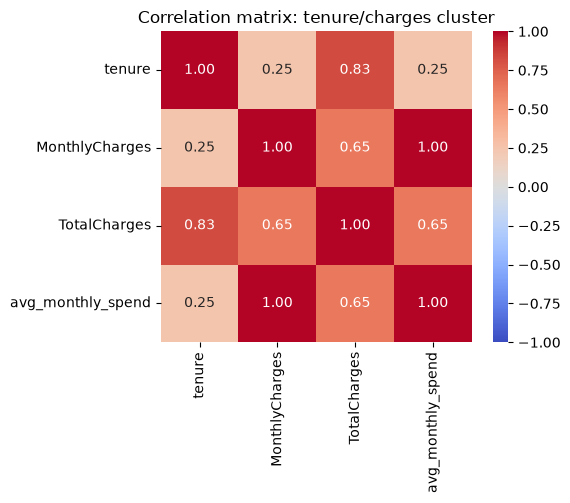

,tenure,MonthlyCharges,TotalCharges,avg_monthly_spend
tenure,1.000000,0.247900,0.826178,0.247234
MonthlyCharges,0.247900,1.000000,0.651174,0.996244
TotalCharges,0.826178,0.651174,1.000000,0.651025
avg_monthly_spend,0.247234,0.996244,0.651025,1.000000


In [19]:
collinearity_cols = ["tenure", "MonthlyCharges", "TotalCharges", "avg_monthly_spend"]

corr_matrix = X[collinearity_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation matrix: tenure/charges cluster")
plt.tight_layout()
plt.show()

corr_matrix

Dropping `TotalCharges` bc it's basicallly `tenure` × `MonthlyCharges` so it's not giving any new information

In [20]:
X = X.drop(columns=["TotalCharges"])

print(f"X: {X.shape[0]:,} rows x {X.shape[1]} columns")
X.head()

X: 7,043 rows x 25 columns


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_No phone service,MultipleLines_Yes,tenure_group,avg_monthly_spend,num_services
0,0,0,1,0,1,0,0,1,0,0,...,0,0,0,1,0,1,0,0,29.850000,1
1,1,0,0,0,34,1,1,0,1,0,...,0,0,0,0,1,0,0,2,55.573529,3
2,1,0,0,0,2,1,1,1,0,0,...,0,0,0,0,1,0,0,0,54.075000,3
3,1,0,0,0,45,0,1,0,1,1,...,0,0,0,0,0,1,0,2,40.905556,3
4,0,0,0,0,2,1,0,0,0,0,...,1,0,0,1,0,0,0,0,75.825000,1


Dropping `avg_monthly_spend`bc of its correlation of 0.996 with `MonthlyCharges. since `avg_monthly_spend = TotalCharges / tenure` and `TotalCharges ≈ tenure × MonthlyCharges`, avg_monthly_spend is not giving any new info than MonthlyCharges

In [21]:
X = X.drop(columns=["avg_monthly_spend"])

print(f"X: {X.shape[0]:,} rows x {X.shape[1]} columns")
X.head()

X: 7,043 rows x 24 columns


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,MonthlyCharges,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_No phone service,MultipleLines_Yes,tenure_group,num_services
0,0,0,1,0,1,0,0,1,0,0,...,29.85,0,0,0,1,0,1,0,0,1
1,1,0,0,0,34,1,1,0,1,0,...,56.95,0,0,0,0,1,0,0,2,3
2,1,0,0,0,2,1,1,1,0,0,...,53.85,0,0,0,0,1,0,0,0,3
3,1,0,0,0,45,0,1,0,1,1,...,42.30,0,0,0,0,0,1,0,2,3
4,0,0,0,0,2,1,0,0,0,0,...,70.70,1,0,0,1,0,0,0,0,1


VIF can show if a feature can be rebuild by combination of other features, if yes, that means it is redundant and should be dropped

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame({
    "feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
vif_df.sort_values("VIF", ascending=False)


c:\Users\katha\ai4all\netflix-churn-predictor\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
6,OnlineSecurity,inf
7,OnlineBackup,inf
5,PhoneService,inf
23,num_services,inf
11,StreamingMovies,inf
10,StreamingTV,inf
9,TechSupport,inf
8,DeviceProtection,inf
14,MonthlyCharges,862.613055
15,InternetService_Fiber optic,148.244350


In [26]:
X = X.drop(columns=["num_services"])

print(f"X: {X.shape[0]:,} rows x {X.shape[1]} columns")
X.head()


X: 7,043 rows x 23 columns


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,PaperlessBilling,MonthlyCharges,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_No phone service,MultipleLines_Yes,tenure_group
0,0,0,1,0,1,0,0,1,0,0,...,1,29.85,0,0,0,1,0,1,0,0
1,1,0,0,0,34,1,1,0,1,0,...,0,56.95,0,0,0,0,1,0,0,2
2,1,0,0,0,2,1,1,1,0,0,...,1,53.85,0,0,0,0,1,0,0,0
3,1,0,0,0,45,0,1,0,1,1,...,0,42.30,0,0,0,0,0,1,0,2
4,0,0,0,0,2,1,0,0,0,0,...,1,70.70,1,0,0,1,0,0,0,0


### Splitting for model training and testing

The random state = 47 (must be fixed always)

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=47
)

print(f"X_train: {X_train.shape[0]:,} rows x {X_train.shape[1]} columns")
print(f"X_test:  {X_test.shape[0]:,} rows x {X_test.shape[1]} columns")


X_train: 5,634 rows x 23 columns
X_test:  1,409 rows x 23 columns


In [30]:
assert len(X_train) + len(X_test) == len(X), "split row counts don't add up"
assert len(y_train) + len(y_test) == len(y), "split row counts don't add up"

print("y_train churn rate:")
print(y_train.value_counts(normalize=True))
print("\ny_test churn rate:")
print(y_test.value_counts(normalize=True))


y_train churn rate:
Churn
No     0.734647
Yes    0.265353
Name: proportion, dtype: float64

y_test churn rate:
Churn
No     0.734564
Yes    0.265436
Name: proportion, dtype: float64


In [31]:
X_train.to_csv("telco-data/X_train.csv", index=False)
X_test.to_csv("telco-data/X_test.csv", index=False)
y_train.to_csv("telco-data/y_train.csv", index=False)
y_test.to_csv("telco-data/y_test.csv", index=False)

print("saved X_train, X_test, y_train, y_test to telco-data/")


saved X_train, X_test, y_train, y_test to telco-data/
